### Import Library

In [1]:
import re
import unicodedata
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

### Load Data

In [2]:
df = pd.read_csv("../dataset/gojek_reviews.csv")
df.head()

,review,score
0,Pokoknya mantap deh naik gojek....keren..,5
1,OK,5
2,"driver tidak bagus, ada yang tdk konfirmasi tr...",2
3,sebenar nya membantu pengiriman tp ada beberap...,3
4,bagus,5


### Cek Identitas Data

In [3]:
print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nTipe data:\n", df.dtypes)

Shape: (70000, 2)

Kolom: ['review', 'score']

Tipe data:
 review      str
score     int64
dtype: object


### Cek Missing Value

In [4]:
df.isna().sum()

review    0
score     0
dtype: int64

### Cek Data Duplikat

In [5]:
df.duplicated(subset=["review"]).sum()

np.int64(21507)

### Drop Data Duplikat

In [6]:
df = df.drop_duplicates(subset=["review"]).copy()

In [7]:
print(len(df))

48493


### Cek Distribusi Skor

In [8]:
print("\nDistribusi score:\n", df["score"].value_counts().sort_index())


Distribusi score:
 score
1    17480
2     2649
3     2438
4     2379
5    23547
Name: count, dtype: int64


### Cek Data (Review) Kosong atau Invalid

In [9]:
df["review_stripped"] = df["review"].str.strip()

In [10]:
empty_mask = df["review_stripped"].eq("") | df["review_stripped"].str.lower().isin(["nan", "none"])
print("Review kosong/invalid:", empty_mask.sum())

Review kosong/invalid: 0


### Pembersihan Data Teks

In [11]:
def clean_text(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URL
    text = re.sub(r"@\w+|#\w+", " ", text)             # mention/hashtag

    # simbol Unicode (termasuk emoji)
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] not in {"S", "C"})

    # menyisakan huruf-angka-spasi
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # spasi
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

In [12]:
before = len(df)
df = df[df["clean_review"].str.len() > 0].copy()
after = len(df)

print("Sebelum:", before)
print("Sesudah:", after)
print("Terhapus:", before - after)

Sebelum: 48493
Sesudah: 48301
Terhapus: 192


### Cek Data Sebelum Labeling

In [13]:
print("Jumlah data akhir:", len(df))
df[["review", "clean_review", "score"]].head(10)

Jumlah data akhir: 48301


,review,clean_review,score
0,Pokoknya mantap deh naik gojek....keren..,pokoknya mantap deh naik gojek keren,5
1,OK,ok,5
2,"driver tidak bagus, ada yang tdk konfirmasi tr...",driver tidak bagus ada yang tdk konfirmasi tru...,2
3,sebenar nya membantu pengiriman tp ada beberap...,sebenar nya membantu pengiriman tp ada beberap...,3
4,bagus,bagus,5
5,sangat bagus,sangat bagus,5
6,suka dengan aplikasinya.,suka dengan aplikasinya,5
7,"driver ranah, sabarrr",driver ranah sabarrr,5
8,ok,ok,5
9,drivernya sekarang malesan kalau mendung dikit...,drivernya sekarang malesan kalau mendung dikit...,1


### Cek Distribusi Skor Setelah Cleaning Data

C:\Users\CHRISTIAN\AppData\Local\Temp\ipykernel_6804\270763424.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


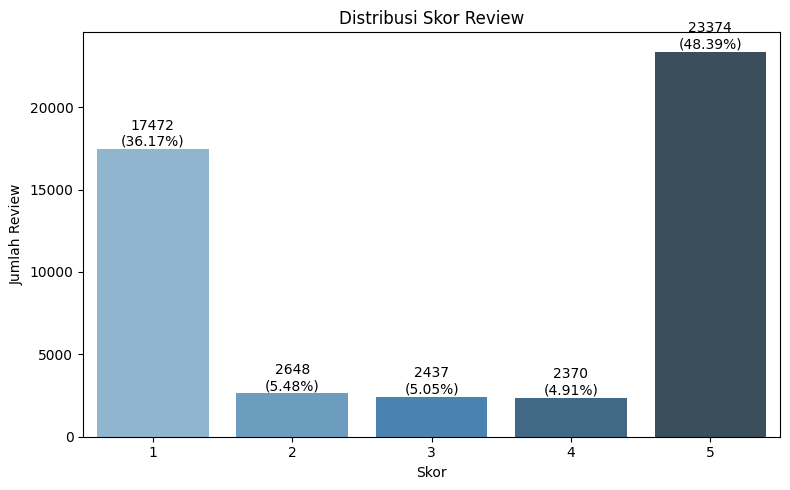

In [14]:
# hitung distribusi
score_counts = df["score"].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(2)

# plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=score_counts.index.astype(str),
    y=score_counts.values,
    palette="Blues_d"
)

# anotasi jumlah + persentase
for i, (count, pct) in enumerate(zip(score_counts.values, score_pct.values)):
    ax.text(i, count, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.title("Distribusi Skor Review")
plt.xlabel("Skor")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.show()

### Labeling Skor

In [15]:
# fungsi untuk labeling
def label_sentiment(score):
    if score <= 2:
        return "negatif"
    elif score == 3:
        return "netral"
    else:
        return "positif"

df["sentiment"] = df["score"].apply(label_sentiment)

# hasil labeling
print("Distribusi label sentimen:")
print(df["sentiment"].value_counts())
df[["clean_review", "score", "sentiment"]].head(10)

Distribusi label sentimen:
sentiment
positif    25744
negatif    20120
netral      2437
Name: count, dtype: int64


,clean_review,score,sentiment
0,pokoknya mantap deh naik gojek keren,5,positif
1,ok,5,positif
2,driver tidak bagus ada yang tdk konfirmasi tru...,2,negatif
3,sebenar nya membantu pengiriman tp ada beberap...,3,netral
4,bagus,5,positif
5,sangat bagus,5,positif
6,suka dengan aplikasinya,5,positif
7,driver ranah sabarrr,5,positif
8,ok,5,positif
9,drivernya sekarang malesan kalau mendung dikit...,1,negatif


### Simpan Dataset Terbaru

In [16]:
df.to_csv("../dataset/gojek_reviews_labeled.csv", index=False)